In [1]:
!pip install matplotlib -q

In [ ]:
import ray
from ray import serve
from ray.llm._internal.serve.deployments.routers.prefix_tree_deployment import PrefixTree
from ray.serve.handle import DeploymentHandle, DeploymentResponse
import time
import matplotlib.pyplot as plt
import numpy as np
import asyncio
import os
import sys
import json
import pandas as pd
from collections import defaultdict
import random
import string

# Create a file for recording timing data in JSON format
TIMING_FILE = "/home/ray/default/work/ray/_prefix_aware_playground/inside_ray/results/deployment_overhead/deployment_overhead_standalone.jsonl"
# Clear the file if it exists
if os.path.exists(TIMING_FILE):
    open(TIMING_FILE, 'w').close()

# Initialize Ray Serve deployment
tree_deployment = PrefixTree.bind()
tree_handle: DeploymentHandle = serve.run(tree_deployment, route_prefix="/prefix-tree")

# Test initial connection
hello_response = await tree_handle.hello.remote()
print(f"Initial test response: {hello_response}")

def generate_random_string(length=1000):
    """Generate a random string of specified length"""
    return ''.join(random.choice(string.ascii_letters + string.digits) for _ in range(length))

async def benchmark_prefix_match_and_insert(handle, num_calls=100):
    """Benchmark both prefix_match and insert operations"""
    for i in range(num_calls):
        request_id = i + 1
        
        # Generate a random string for this request
        random_text = generate_random_string(1000)
        tenant = f"tenant_{request_id % 10}"  # Use 10 different tenants
        
        # Record time before calling prefix_match
        t0_prefix = time.time()
        with open(TIMING_FILE, "a") as f:
            f.write(json.dumps({
                "request_id": request_id,
                "stage": "before_calling_prefix_match",
                "timestamp": t0_prefix
            }) + "\n")
        
        # Call prefix_match
        matched_text, matched_tenant, _ = await handle.prefix_match.remote(
            text=random_text,
            output_file=TIMING_FILE,
            request_id=request_id
        )
        
        # Record time after receiving prefix_match response
        t3_prefix = time.time()
        with open(TIMING_FILE, "a") as f:
            f.write(json.dumps({
                "request_id": request_id,
                "stage": "after_calling_prefix_match",
                "timestamp": t3_prefix
            }) + "\n")
        
        # Record time before calling insert
        t0_insert = time.time()
        with open(TIMING_FILE, "a") as f:
            f.write(json.dumps({
                "request_id": request_id,
                "stage": "before_calling_insert",
                "timestamp": t0_insert
            }) + "\n")
        
        # Call insert
        await handle.insert.remote(
            text=random_text,
            tenant=tenant,
            output_file=TIMING_FILE,
            request_id=request_id
        )
        
        # Record time after receiving insert response
        t3_insert = time.time()
        with open(TIMING_FILE, "a") as f:
            f.write(json.dumps({
                "request_id": request_id,
                "stage": "after_calling_insert",
                "timestamp": t3_insert
            }) + "\n")
    
    print(f"Completed {num_calls} benchmark calls")

def parse_timing_data(file_path):
    """Parse the JSON Lines timing data from the file"""
    # Define stage name mapping for better readability
    stage_mapping = {
        # Client-side timing points
        "before_calling_prefix_match": "client_prefix_start",
        "after_calling_prefix_match": "client_prefix_end",
        "before_calling_insert": "client_insert_start",
        "after_calling_insert": "client_insert_end",
        
        # Server-side timing points
        "received_by_prefix_match": "server_prefix_start",
        "completed_prefix_match": "server_prefix_end",
        "received_by_insert": "server_insert_start",
        "completed_insert": "server_insert_end"
    }
    
    # Map for defining the phases we'll measure
    phase_definitions = [
        # Prefix match phases
        {"name": "prefix_match_client_to_server", "start": "client_prefix_start", "end": "server_prefix_start"},
        {"name": "prefix_match_processing", "start": "server_prefix_start", "end": "server_prefix_end"},
        {"name": "prefix_match_server_to_client", "start": "server_prefix_end", "end": "client_prefix_end"},
        {"name": "prefix_match_total", "start": "client_prefix_start", "end": "client_prefix_end"},
        
        # Insert phases
        {"name": "insert_client_to_server", "start": "client_insert_start", "end": "server_insert_start"},
        {"name": "insert_processing", "start": "server_insert_start", "end": "server_insert_end"},
        {"name": "insert_server_to_client", "start": "server_insert_end", "end": "client_insert_end"},
        {"name": "insert_total", "start": "client_insert_start", "end": "client_insert_end"},
        
        # Overall request time
        {"name": "total_request_time", "start": "client_prefix_start", "end": "client_insert_end"}
    ]
    
    # Read the timing data
    request_data = defaultdict(dict)
    with open(file_path, 'r') as f:
        for line in f:
            entry = json.loads(line.strip())
            request_id = entry["request_id"]
            stage = entry["stage"]
            timestamp = entry["timestamp"]
            
            # Store using mapped names
            if stage in stage_mapping:
                request_data[request_id][stage_mapping[stage]] = timestamp
    
    # Calculate durations for each phase
    durations = {phase["name"]: [] for phase in phase_definitions}
    
    for req_id, times in request_data.items():
        for phase in phase_definitions:
            start_key = phase["start"]
            end_key = phase["end"]
            
            if start_key in times and end_key in times:
                duration = times[end_key] - times[start_key]
                durations[phase["name"]].append(duration)
    
    return durations, request_data

def plot_phase_durations(durations):
    """Create a grouped bar chart showing average duration for each phase"""
    # Group the phases by operation
    operation_groups = {
        "Prefix Match": ["prefix_match_client_to_server", "prefix_match_processing", "prefix_match_server_to_client", "prefix_match_total"],
        "Insert": ["insert_client_to_server", "insert_processing", "insert_server_to_client", "insert_total"],
        "Total": ["total_request_time"]
    }
    
    # Define stage descriptions for the legend
    stage_descriptions = {
        "prefix_match_client_to_server": "Client to Server",
        "prefix_match_processing": "Server Processing",
        "prefix_match_server_to_client": "Server to Client",
        "prefix_match_total": "Total Round Trip",
        "insert_client_to_server": "Client to Server",
        "insert_processing": "Server Processing",
        "insert_server_to_client": "Server to Client",
        "insert_total": "Total Round Trip",
        "total_request_time": "Complete Operation"
    }
    
    # Create figure with subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 8))
    
    # Plot each operation group in a separate subplot
    for i, (group_name, phase_names) in enumerate(operation_groups.items()):
        phases = [phase for phase in phase_names if phase in durations and durations[phase]]
        avg_durations = [np.mean(durations[phase]) * 1000 for phase in phases]  # Convert to milliseconds
        labels = [stage_descriptions[phase] for phase in phases]
        
        # Create the bar chart
        bars = axs[i].bar(labels, avg_durations)
        
        # Add values on top of bars
        for bar, duration in zip(bars, avg_durations):
            axs[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{duration:.2f} ms', ha='center', fontsize=9)
        
        axs[i].set_title(f'{group_name} Operation Durations')
        axs[i].set_ylabel('Duration (milliseconds)')
        axs[i].tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    plt.show()
    
    # Create a single bar chart with all individual phases
    plt.figure(figsize=(15, 8))
    
    # Select only the non-total phases for a clearer visualization
    detailed_phases = [
        "prefix_match_client_to_server", "prefix_match_processing", "prefix_match_server_to_client",
        "insert_client_to_server", "insert_processing", "insert_server_to_client"
    ]
    
    detailed_phases = [p for p in detailed_phases if p in durations and durations[p]]
    detailed_labels = [stage_descriptions[p] + f" ({p.split('_')[0].capitalize()})" for p in detailed_phases]
    detailed_durations = [np.mean(durations[p]) * 1000 for p in detailed_phases]
    
    # Colors for different operations
    colors = ['#1f77b4', '#1f77b4', '#1f77b4', '#ff7f0e', '#ff7f0e', '#ff7f0e']
    
    # Create the detailed bar chart
    bars = plt.bar(detailed_labels, detailed_durations, color=colors)
    
    # Add values on top of bars
    for bar, duration in zip(bars, detailed_durations):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
               f'{duration:.2f} ms', ha='center')
    
    plt.title('Detailed Phase Durations for Each Operation')
    plt.ylabel('Duration (milliseconds)')
    plt.xlabel('Operation Phase')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\nDetailed Statistics (in milliseconds):")
    for group_name, phase_names in operation_groups.items():
        print(f"\n{group_name} Operation:")
        for phase in phase_names:
            if phase in durations and durations[phase]:
                data = np.array(durations[phase]) * 1000  # Convert to milliseconds
                print(f"  {stage_descriptions[phase]}:")
                print(f"    Average: {np.mean(data):.3f} ms")
                print(f"    Min: {np.min(data):.3f} ms")
                print(f"    Max: {np.max(data):.3f} ms")
                print(f"    Std Dev: {np.std(data):.3f} ms")
            else:
                print(f"  {stage_descriptions.get(phase, phase)}: No data")

async def run_benchmarks(num_calls=100):
    # Run the detailed benchmark for both prefix_match and insert
    await benchmark_prefix_match_and_insert(tree_handle, num_calls)
    
    # Parse and visualize the timing data
    durations, raw_data = parse_timing_data(TIMING_FILE)
    plot_phase_durations(durations)

# For Jupyter notebooks or environments with existing event loops:
await run_benchmarks(num_calls=1000)  # You can adjust the number of calls

# For regular Python scripts:
# if __name__ == "__main__":
#     asyncio.run(run_benchmarks(num_calls=50))

In [19]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

def parse_timing_data(file_path):
    """Parse JSONL timing data and calculate durations"""
    # Define the stages as they appear in the logs
    phase_definitions = [
        {"name": "prefix_match_client_to_server", "start": "before_calling_prefix_match", "end": "received_by_prefix_match"},
        {"name": "prefix_match_processing", "start": "received_by_prefix_match", "end": "completed_prefix_match"},
        {"name": "prefix_match_server_to_client", "start": "completed_prefix_match", "end": "after_calling_prefix_match"},
        {"name": "prefix_match_total", "start": "before_calling_prefix_match", "end": "after_calling_prefix_match"},
        {"name": "insert_client_to_server", "start": "before_calling_insert", "end": "received_by_insert"},
        {"name": "insert_processing", "start": "received_by_insert", "end": "completed_insert"},
        {"name": "insert_server_to_client", "start": "completed_insert", "end": "after_calling_insert"},
        {"name": "insert_total", "start": "before_calling_insert", "end": "after_calling_insert"},
        {"name": "total_request_time", "start": "before_calling_prefix_match", "end": "after_calling_insert"},
    ]

    # Read the data directly since each line contains all stages for a request
    request_data = {}
    with open(file_path, 'r') as f:
        for line in f:
            entry = json.loads(line.strip())
            req_id = entry["request_id"]
            request_data[req_id] = entry

    # Calculate durations for each phase
    durations = {phase["name"]: [] for phase in phase_definitions}
    for req_id, times in request_data.items():
        for phase in phase_definitions:
            start, end = phase["start"], phase["end"]
            if start in times and end in times:
                durations[phase["name"]].append(times[end] - times[start])
                
    return durations, request_data

def plot_phase_durations(durations, title=None):
    operation_groups = {
        "Prefix Match": [
            "prefix_match_client_to_server", "prefix_match_processing",
            "prefix_match_server_to_client", "prefix_match_total"
        ],
        "Insert": [
            "insert_client_to_server", "insert_processing",
            "insert_server_to_client", "insert_total"
        ],
        "Total": ["total_request_time"]
    }

    stage_descriptions = {
        "prefix_match_client_to_server": "Client to Server",
        "prefix_match_processing": "Server Processing",
        "prefix_match_server_to_client": "Server to Client",
        "prefix_match_total": "Total Round Trip",
        "insert_client_to_server": "Client to Server",
        "insert_processing": "Server Processing",
        "insert_server_to_client": "Server to Client",
        "insert_total": "Total Round Trip",
        "total_request_time": "Complete Operation"
    }

    # fig, axs = plt.subplots(1, 3, figsize=(18, 8))
    # for i, (group_name, phase_names) in enumerate(operation_groups.items()):
    #     phases = [p for p in phase_names if p in durations and durations[p]]
    #     avg_durations = [np.mean(durations[p]) * 1000 for p in phases]
    #     labels = [stage_descriptions[p] for p in phases]

    #     bars = axs[i].bar(labels, avg_durations)
    #     for bar, duration in zip(bars, avg_durations):
    #         axs[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
    #                     f'{duration:.2f} ms', ha='center', fontsize=9)

    #     axs[i].set_title(f'{group_name} Operation Durations')
    #     axs[i].set_ylabel('Duration (ms)')
    #     axs[i].tick_params(axis='x', rotation=15)

    # if title:
    #     fig.suptitle(title, fontsize=16)
    # plt.tight_layout()
    # plt.show()

    # Detailed chart
    plt.figure(figsize=(10, 5))
    detailed_phases = [
        "prefix_match_client_to_server", "prefix_match_processing", "prefix_match_server_to_client",
        "insert_client_to_server", "insert_processing", "insert_server_to_client"
    ]
    detailed_labels = [stage_descriptions[p] + f" ({p.split('_')[0].capitalize()})" for p in detailed_phases]
    detailed_durations = [np.mean(durations[p]) * 1000 for p in detailed_phases if p in durations and durations[p]]
    
    # Calculate the total as sum of all other bars
    total_duration = sum(detailed_durations)
    detailed_labels.append("Total")
    detailed_durations.append(total_duration)
    
    # Colors for the bars - blue for prefix match, orange for insert, green for total
    colors = ['#1f77b4'] * 3 + ['#ff7f0e'] * 3 + ['#2ca02c']

    # Get number of requests
    num_requests = len(next(iter(durations.values()))) if durations else 0

    bars = plt.bar(detailed_labels, detailed_durations, color=colors)
    for bar, duration in zip(bars, detailed_durations):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{duration:.2f} ms', ha='center')

    plt.title(f'Deployment Overhead Breakdown ({num_requests} requests){" - " + title if title else ""}')
    plt.ylabel('Duration (ms)')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # print("\nDetailed Statistics (in milliseconds):")
    # for group_name, phase_names in operation_groups.items():
    #     print(f"\n{group_name} Operation:")
    #     for phase in phase_names:
    #         if phase in durations and durations[phase]:
    #             data = np.array(durations[phase]) * 1000
    #             print(f"  {stage_descriptions[phase]}:")
    #             print(f"    Avg: {np.mean(data):.3f} ms")
    #             print(f"    Min: {np.min(data):.3f} ms")
    #             print(f"    Max: {np.max(data):.3f} ms")
    #             print(f"    Std Dev: {np.std(data):.3f} ms")
    #         else:
    #             print(f"  {stage_descriptions.get(phase, phase)}: No data")


{'prefix_match_client_to_server': [0.012581825256347656, 0.003761768341064453, 0.0018222332000732422, 0.001779794692993164, 0.0024437904357910156, 0.004346132278442383, 0.003278970718383789, 0.0044019222259521484, 0.002432584762573242, 0.0023162364959716797, 0.002637147903442383, 0.003084897994995117, 0.004475831985473633, 0.0025794506072998047, 0.0025594234466552734, 0.0021452903747558594, 0.002118349075317383, 0.002923727035522461, 0.002256155014038086, 0.0023956298828125, 0.0031862258911132812, 0.002516508102416992, 0.00243377685546875, 0.002698659896850586, 0.005064249038696289, 0.0020236968994140625, 0.0017523765563964844, 0.002266407012939453, 0.007899999618530273, 0.004011869430541992, 0.002366304397583008, 0.0021059513092041016, 0.002335786819458008, 0.002035856246948242, 0.0023221969604492188, 0.001959562301635742, 0.0021750926971435547, 0.0024480819702148438, 0.003814697265625, 0.0018568038940429688, 0.002375364303588867, 0.002805948257446289, 0.002424478530883789, 0.00318503

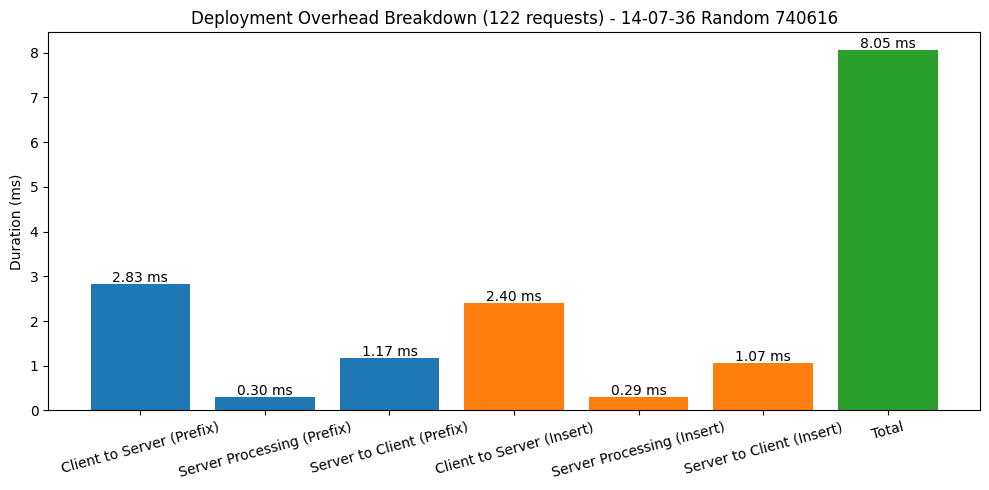

{'prefix_match_client_to_server': [0.012292623519897461, 0.0042378902435302734, 0.004621982574462891, 0.002104520797729492, 0.002833127975463867, 0.0020265579223632812, 0.0028426647186279297, 0.003771543502807617, 0.002257108688354492, 0.0038225650787353516, 0.0019490718841552734, 0.0023322105407714844, 0.002395153045654297, 0.002235889434814453, 0.0019588470458984375, 0.002113819122314453, 0.0021479129791259766, 0.003643512725830078, 0.0025811195373535156, 0.003053903579711914, 0.002268552780151367, 0.0026400089263916016, 0.0040819644927978516, 0.0023043155670166016, 0.0021381378173828125, 0.002570629119873047, 0.002332448959350586, 0.003760814666748047, 0.003021717071533203, 0.0024213790893554688, 0.0025300979614257812, 0.004369974136352539, 0.002431631088256836, 0.0036885738372802734, 0.0024857521057128906, 0.0019483566284179688, 0.002846240997314453, 0.002170085906982422, 0.0022592544555664062, 0.0024251937866210938, 0.002155303955078125, 0.0024352073669433594, 0.005572080612182617

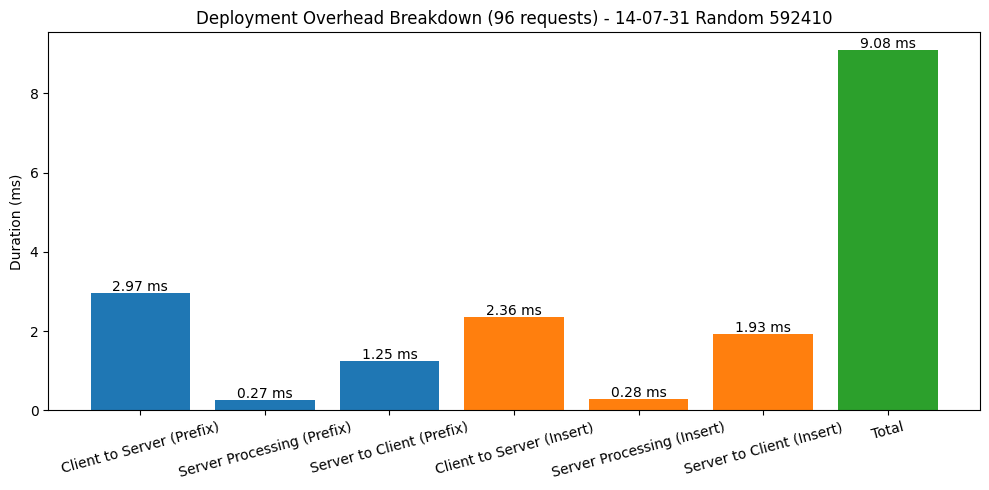

{'prefix_match_client_to_server': [0.009986639022827148, 0.008076190948486328, 0.003366708755493164, 0.001875162124633789, 0.002714872360229492, 0.0025207996368408203, 0.002442598342895508, 0.00211334228515625, 0.002330303192138672, 0.002111673355102539, 0.002271413803100586, 0.0023856163024902344, 0.0024950504302978516, 0.002167224884033203, 0.0021712779998779297, 0.002345561981201172, 0.005974769592285156, 0.002434253692626953, 0.002198457717895508, 0.00496673583984375, 0.0022094249725341797, 0.004840373992919922, 0.003180980682373047, 0.002399921417236328, 0.002509593963623047, 0.002537250518798828, 0.0027937889099121094, 0.002332925796508789, 0.0017957687377929688, 0.002657175064086914, 0.0023190975189208984, 0.004548072814941406, 0.001897573471069336, 0.0020194053649902344, 0.004246711730957031, 0.003122568130493164, 0.0027358531951904297, 0.002401590347290039, 0.0036640167236328125, 0.0023946762084960938, 0.0022766590118408203, 0.0017535686492919922, 0.0026252269744873047, 0.0023

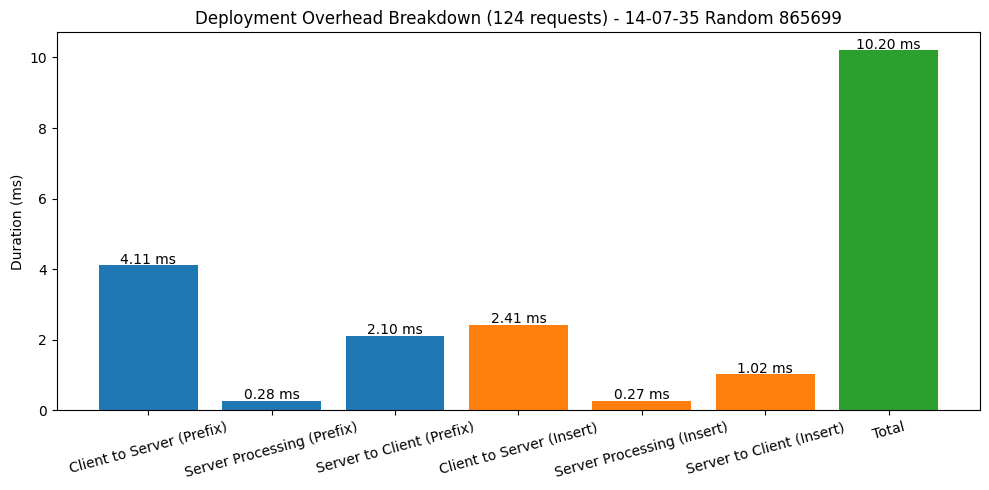

{'prefix_match_client_to_server': [0.016754627227783203, 0.0035250186920166016, 0.0026733875274658203, 0.002034425735473633, 0.004527091979980469, 0.002284526824951172, 0.0017693042755126953, 0.0032999515533447266, 0.00244903564453125, 0.004086732864379883, 0.003378629684448242, 0.0024900436401367188, 0.002989530563354492, 0.0019350051879882812, 0.0023403167724609375, 0.002170562744140625, 0.002614736557006836, 0.004256725311279297, 0.002529621124267578, 0.0021200180053710938, 0.0025479793548583984, 0.001981496810913086, 0.0027632713317871094, 0.004065275192260742, 0.002266407012939453, 0.0025682449340820312, 0.002396821975708008, 0.0023910999298095703, 0.0023365020751953125, 0.0022783279418945312, 0.003101825714111328, 0.0023658275604248047, 0.0040585994720458984, 0.002475261688232422, 0.0028505325317382812, 0.002615690231323242, 0.0023996829986572266, 0.00400853157043457, 0.0021491050720214844, 0.0033707618713378906, 0.002588987350463867, 0.002235889434814453, 0.0019161701202392578, 

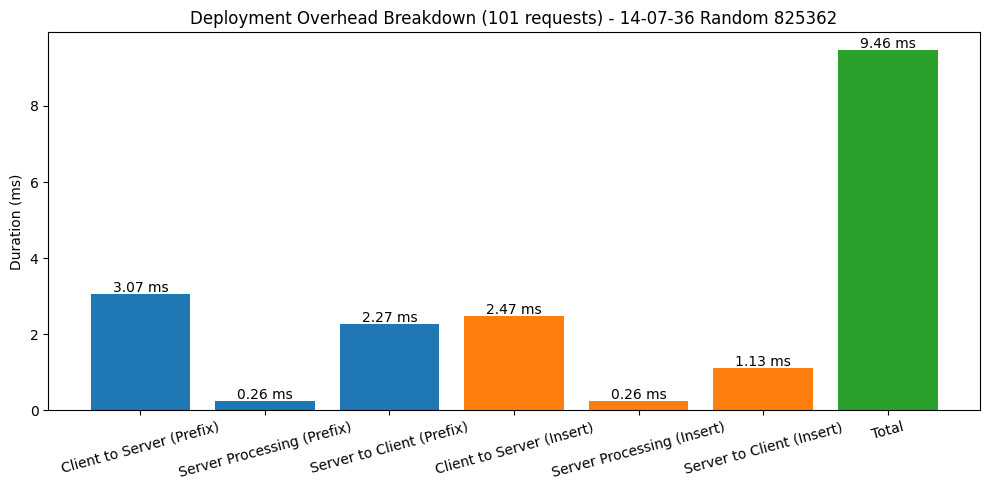

{'prefix_match_client_to_server': [0.014285564422607422, 0.0019135475158691406, 0.18744683265686035, 0.0024368762969970703, 0.002446889877319336, 0.002286672592163086, 0.002313375473022461, 0.0022187232971191406, 0.0016202926635742188, 0.0022766590118408203, 0.0025141239166259766, 0.0022597312927246094, 0.0026128292083740234, 0.0022623538970947266, 0.002010822296142578, 0.0022335052490234375, 0.0023546218872070312, 0.0035247802734375, 0.0024759769439697266, 0.002707958221435547, 0.0017523765563964844, 0.002418994903564453, 0.002984762191772461, 0.0017359256744384766, 0.0022923946380615234, 0.0021293163299560547, 0.0018270015716552734, 0.002105236053466797, 0.002191305160522461, 0.004061698913574219, 0.003798246383666992, 0.0031280517578125, 0.002424001693725586, 0.0031735897064208984, 0.0019385814666748047, 0.0025746822357177734, 0.002186298370361328, 0.0035059452056884766, 0.00921773910522461, 0.003949880599975586, 0.004954814910888672, 0.0030438899993896484, 0.002183198928833008, 0.0

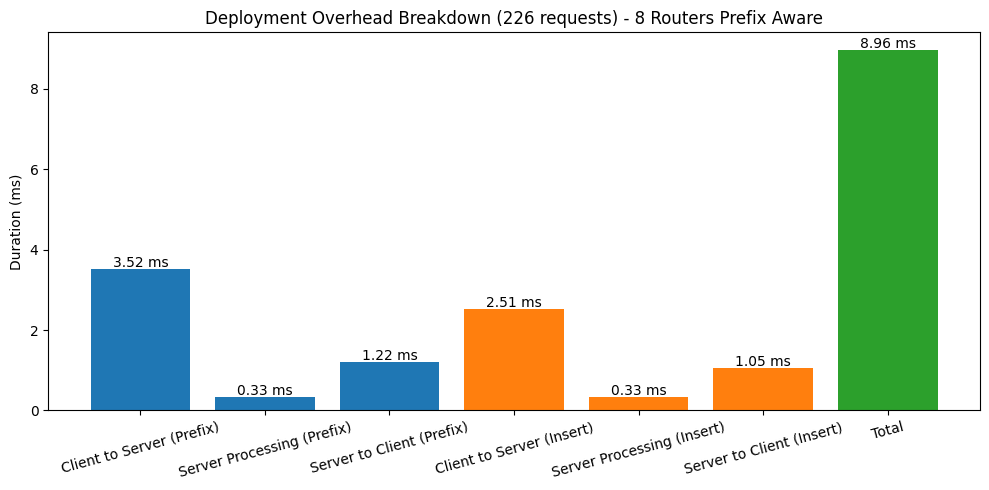

{'prefix_match_client_to_server': [0.01277470588684082, 0.0016484260559082031, 0.0027158260345458984, 0.0021677017211914062, 0.0023469924926757812, 0.002087831497192383, 0.0023374557495117188, 0.0026407241821289062, 0.0024704933166503906, 0.0031461715698242188, 0.0027725696563720703, 0.002869844436645508, 0.0030066967010498047, 0.0016224384307861328, 0.0025413036346435547, 0.0022716522216796875, 0.0023877620697021484, 0.002458333969116211, 0.0020296573638916016, 0.003137826919555664, 0.0035355091094970703, 0.004642486572265625, 0.002142667770385742, 0.0028333663940429688, 0.0027544498443603516, 0.0032439231872558594, 0.0021398067474365234, 0.0027303695678710938, 0.0022323131561279297, 0.003430604934692383, 0.0024302005767822266, 0.0023212432861328125, 0.0045397281646728516, 0.0029637813568115234, 0.0023424625396728516, 0.002410888671875, 0.002298116683959961, 0.002182483673095703, 0.004072427749633789, 0.003574848175048828, 0.002984762191772461, 0.002471446990966797, 0.0023913383483886

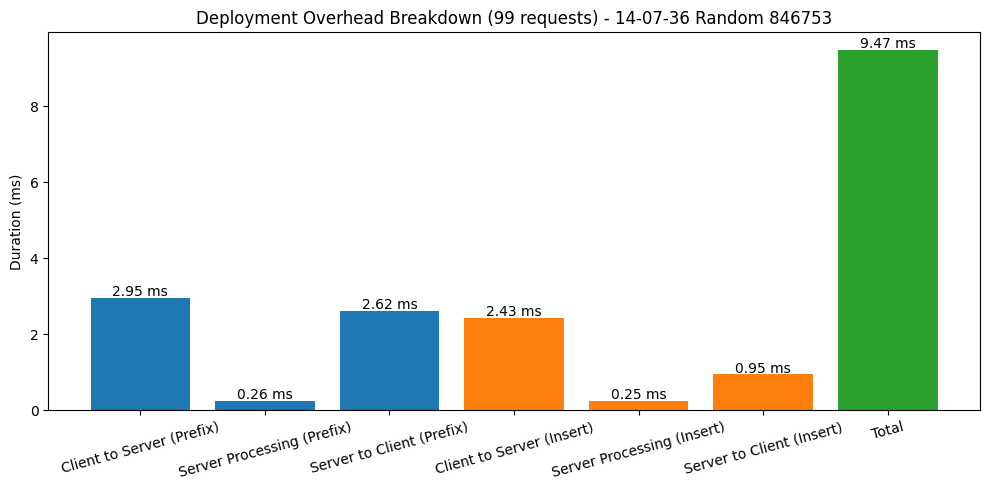

{'prefix_match_client_to_server': [0.021345853805541992, 0.0027768611907958984, 0.0021669864654541016, 0.0030918121337890625, 0.0024995803833007812, 0.002364635467529297, 0.0027916431427001953, 0.0025484561920166016, 0.002340078353881836, 0.004216194152832031, 0.0020291805267333984, 0.0024940967559814453, 0.0022916793823242188, 0.002165555953979492, 0.002521514892578125, 0.002331256866455078, 0.004023551940917969, 0.0021822452545166016, 0.003123044967651367, 0.0018687248229980469, 0.004033565521240234, 0.002777576446533203, 0.0026988983154296875, 0.0026984214782714844, 0.003175020217895508, 0.00250244140625, 0.003182649612426758, 0.002497434616088867, 0.0023949146270751953, 0.0019979476928710938, 0.0052525997161865234, 0.0023849010467529297, 0.002508878707885742, 0.005582094192504883, 0.0022690296173095703, 0.002809762954711914, 0.0021533966064453125, 0.002186298370361328, 0.002437591552734375, 0.002285480499267578, 0.0018987655639648438, 0.0021338462829589844, 0.0029256343841552734, 0

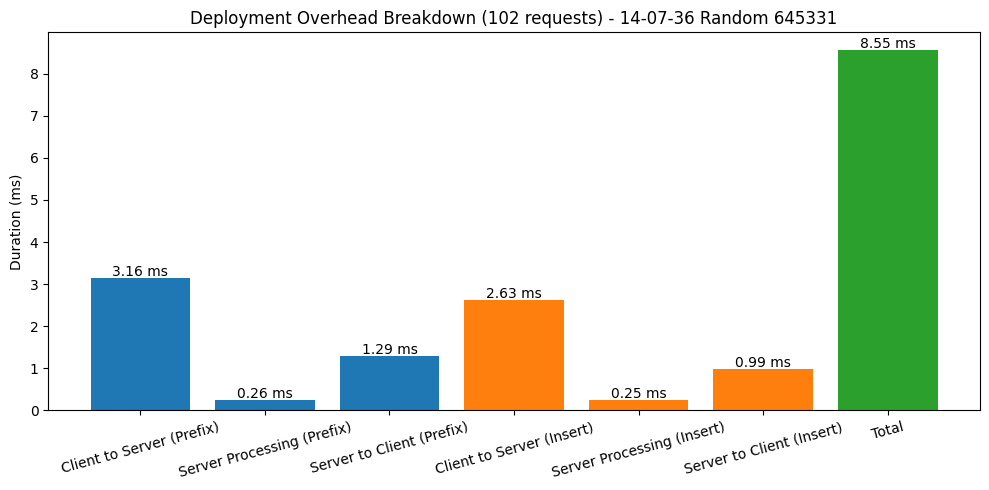

{'prefix_match_client_to_server': [0.012197732925415039, 0.0018000602722167969, 0.0035355091094970703, 0.0021665096282958984, 0.0019996166229248047, 0.004290103912353516, 0.002225637435913086, 0.002263307571411133, 0.00394439697265625, 0.0021238327026367188, 0.002263784408569336, 0.002655029296875, 0.0020515918731689453, 0.005198240280151367, 0.002300262451171875, 0.0018739700317382812, 0.003314971923828125, 0.0017237663269042969, 0.004060268402099609, 0.00266265869140625, 0.002562999725341797, 0.0027735233306884766, 0.00403904914855957, 0.003073453903198242, 0.002407073974609375, 0.0022704601287841797, 0.0037033557891845703, 0.0020079612731933594, 0.0022907257080078125, 0.0022077560424804688, 0.0027272701263427734, 0.002729654312133789, 0.004135608673095703, 0.003123760223388672, 0.0038874149322509766, 0.002530336380004883, 0.002566099166870117, 0.002228260040283203, 0.0017282962799072266, 0.0027022361755371094, 0.006465911865234375, 0.003790140151977539, 0.003016948699951172, 0.00217

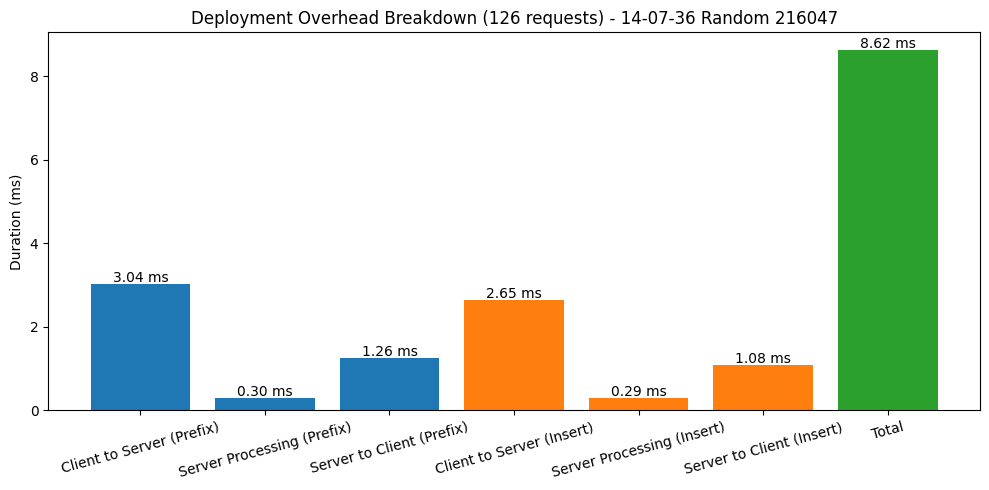

{'prefix_match_client_to_server': [0.01452183723449707, 0.004583597183227539, 0.002045869827270508, 0.002837657928466797, 0.002505779266357422, 0.004133462905883789, 0.0020589828491210938, 0.003134489059448242, 0.0029408931732177734, 0.002246856689453125, 0.002935171127319336, 0.002451658248901367, 0.002421855926513672, 0.0027723312377929688, 0.0024657249450683594, 0.002262592315673828, 0.0024743080139160156, 0.0026504993438720703, 0.0024614334106445312, 0.002393960952758789, 0.002682924270629883, 0.0019452571868896484, 0.0030014514923095703, 0.0028710365295410156, 0.0024499893188476562, 0.004774808883666992, 0.002058744430541992, 0.002377033233642578, 0.003078460693359375, 0.0032432079315185547, 0.0016934871673583984, 0.0019617080688476562, 0.0020706653594970703, 0.005596637725830078, 0.0022592544555664062, 0.0022971630096435547, 0.002560853958129883, 0.002045154571533203, 0.004773378372192383, 0.002254962921142578, 0.0022039413452148438, 0.0024225711822509766, 0.002972841262817383, 0

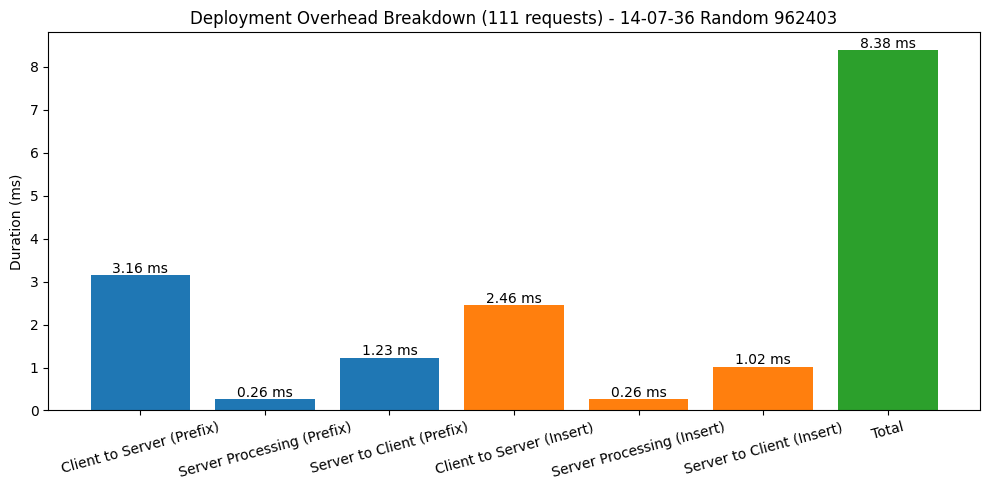

{'prefix_match_client_to_server': [0.01160287857055664, 0.0025713443756103516, 0.0029134750366210938, 0.0028798580169677734, 0.00543975830078125, 0.2093064785003662, 0.020936012268066406, 0.0048406124114990234, 0.005921840667724609, 0.006738185882568359, 0.005038022994995117, 0.009762287139892578, 0.00933074951171875, 0.010778427124023438, 0.011406898498535156, 0.006592988967895508, 0.011346578598022461, 0.0073049068450927734, 0.00891876220703125, 0.012398481369018555, 0.01172327995300293, 0.010391473770141602, 0.009453296661376953, 0.004631519317626953, 0.006094455718994141, 0.00563502311706543, 0.004963397979736328, 0.0065555572509765625, 0.005820751190185547, 0.005468606948852539, 0.005133628845214844, 0.005645036697387695, 0.00507664680480957, 0.005022764205932617, 0.004992008209228516, 0.007182598114013672, 0.007073879241943359, 0.006331443786621094, 0.00513768196105957, 0.004145622253417969, 0.0050907135009765625, 0.002244710922241211, 0.0040624141693115234, 0.008642911911010742,

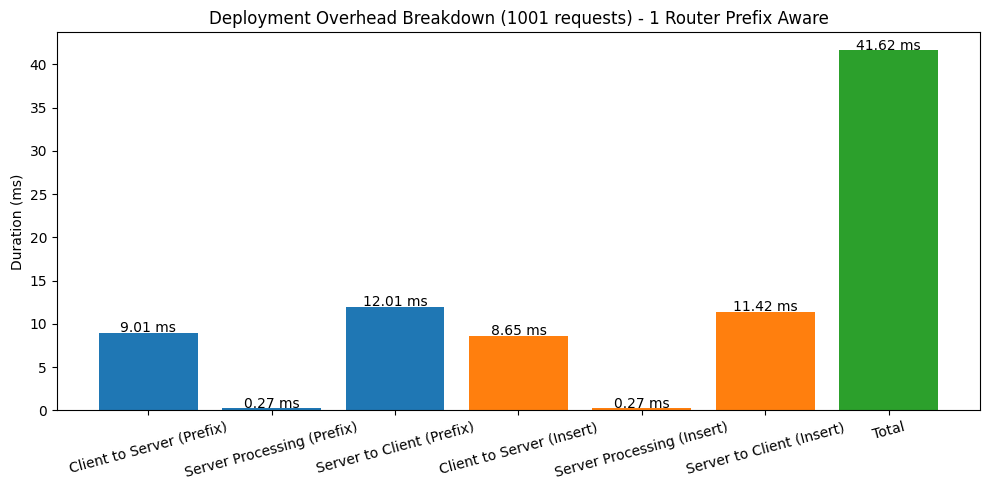

In [20]:
import os
import glob

# Get all timing files in the deployment_overhead directory
timing_files = glob.glob("/home/ray/default/work/ray/_prefix_aware_playground/inside_ray/results/deployment_overhead/*.jsonl")

# Process each file
for timing_file in timing_files:
    # Extract the filename without path and extension for the title
    filename = os.path.basename(timing_file)
    title = filename.replace(".jsonl", "").replace("_", " ").title()
    
    # print(f"Processing: {filename}")
    
    # Parse and visualize the data
    durations, raw_data = parse_timing_data(timing_file)
    plot_phase_durations(durations, title=title)